In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("data/cleaned_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8790, 16)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month,added_day,duration_value,duration_type,primary_genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,25,90,min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,24,1,Seasons,Crime TV Shows
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,24,1,Seasons,TV Dramas
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,22,91,min,Children & Family Movies
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,24,125,min,Dramas


In [3]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
show_id           0
type              0
title             0
director          0
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
added_year        0
added_month       0
added_day         0
duration_value    0
duration_type     0
primary_genre     0
dtype: int64

Duplicate Rows: 0

Data Types:
show_id             str
type                str
title               str
director            str
country             str
date_added          str
release_year      int64
rating              str
duration            str
listed_in           str
added_year        int64
added_month       int64
added_day         int64
duration_value    int64
duration_type       str
primary_genre       str
dtype: object


In [4]:
# Business KPIs

total_titles = len(df)
total_movies = (df["type"] == "Movie").sum()
total_tv_shows = (df["type"] == "TV Show").sum()

movie_percentage = round((total_movies / total_titles) * 100, 2)
tv_show_percentage = round((total_tv_shows / total_titles) * 100, 2)

latest_release_year = df["release_year"].max()
earliest_release_year = df["release_year"].min()

top_genre = df["primary_genre"].value_counts().idxmax()
top_genre_count = df["primary_genre"].value_counts().max()

top_country = df["country"].value_counts().idxmax()
top_country_count = df["country"].value_counts().max()

top_rating = df["rating"].value_counts().idxmax()
top_rating_count = df["rating"].value_counts().max()

print("===== NETFLIX CONTENT KPIs =====")
print(f"Total Titles: {total_titles}")
print(f"Movies: {total_movies} ({movie_percentage}%)")
print(f"TV Shows: {total_tv_shows} ({tv_show_percentage}%)")
print(f"Release Year Range: {earliest_release_year} - {latest_release_year}")
print(f"Top Genre: {top_genre} ({top_genre_count} titles)")
print(f"Top Country: {top_country} ({top_country_count} titles)")
print(f"Most Common Rating: {top_rating} ({top_rating_count} titles)")

===== NETFLIX CONTENT KPIs =====
Total Titles: 8790
Movies: 6126 (69.69%)
TV Shows: 2664 (30.31%)
Release Year Range: 1925 - 2021
Top Genre: Dramas (1599 titles)
Top Country: United States (3240 titles)
Most Common Rating: TV-MA (3205 titles)


Content Type Distribution:
type
Movie      6126
TV Show    2664
Name: count, dtype: int64


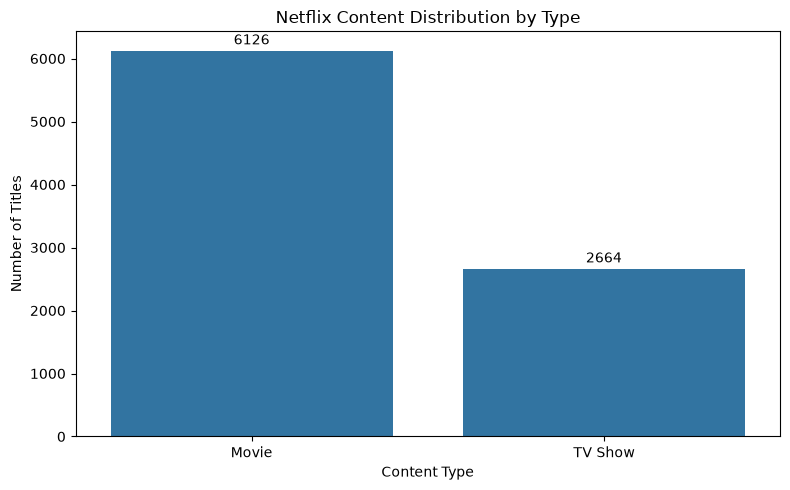

In [5]:
# Content Type Analysis

type_counts = df["type"].value_counts()

print("Content Type Distribution:")
print(type_counts)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=type_counts.index,
    y=type_counts.values
)

plt.title("Netflix Content Distribution by Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

for i, value in enumerate(type_counts.values):
    ax.text(i, value + 100, str(value), ha="center")
    
plt.tight_layout()
plt.show()

Top 10 Genres:
primary_genre
Dramas                      1599
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64


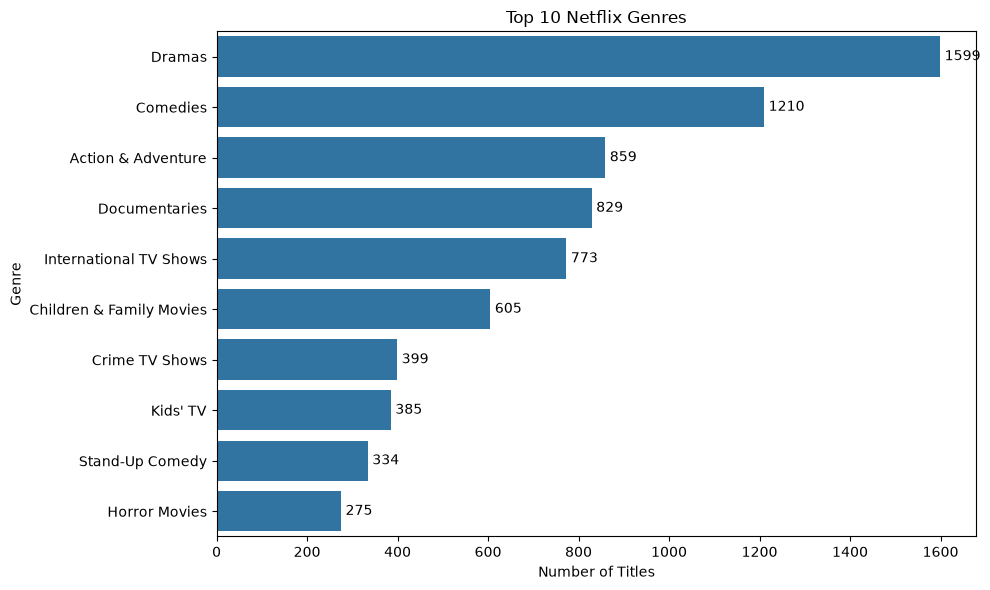

In [6]:
# Top Genres

genre_counts = df["primary_genre"].value_counts().head(10)

print("Top 10 Genres:")
print(genre_counts)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

for i, value in enumerate(genre_counts.values):
    ax.text(value + 10, i, str(value), va="center")

plt.tight_layout()
plt.show()

Top 10 Countries by Number of Titles:
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64


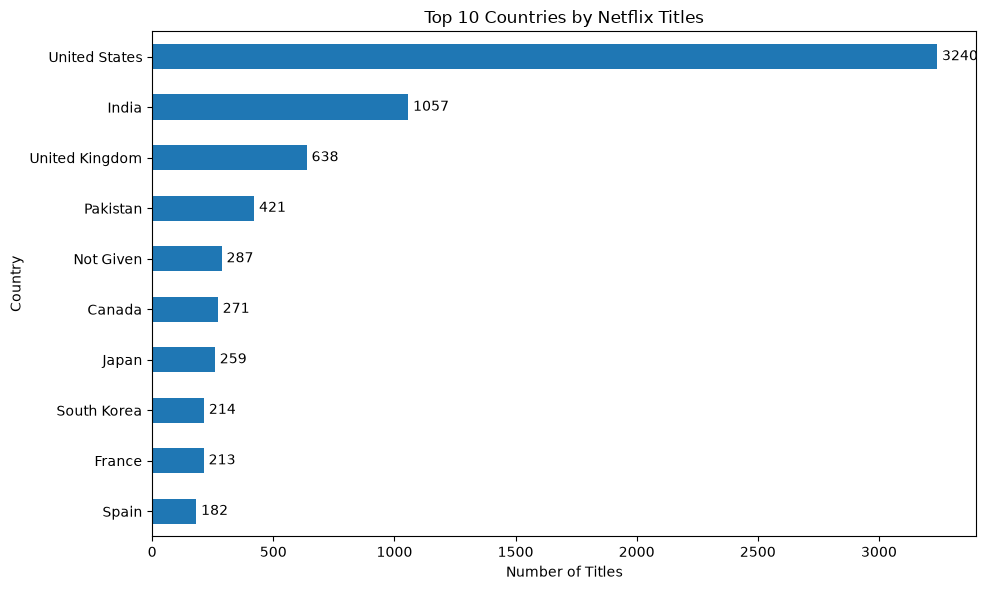

In [7]:
# ==============================
# COUNTRY ANALYSIS
# ==============================

country_counts = df["country"].value_counts().head(10)

print("Top 10 Countries by Number of Titles:")
print(country_counts)

plt.figure(figsize=(10, 6))

country_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

for i, value in enumerate(country_counts.sort_values()):
    plt.text(value + 20, i, str(value), va="center")

plt.tight_layout()
plt.show()

In [8]:
top_country = country_counts.index[0]
top_country_count = country_counts.iloc[0]

print(f"Top Country: {top_country}")
print(f"Number of Titles: {top_country_count}")

Top Country: United States
Number of Titles: 3240


In [9]:
# ============================================
# PREDICTIVE MODEL - CONTENT GROWTH
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Yearly content additions
yearly_content = (
    df.groupby("added_year")
    .size()
    .reset_index(name="title_count")
)

# Remove years with very low historical coverage
yearly_content = yearly_content[
    yearly_content["added_year"] >= 2013
].copy()

print("Yearly Content Data:")
display(yearly_content)

# Features and target
X = yearly_content[["added_year"]]
y = yearly_content["title_count"]

# Chronological train-test split
split_index = int(len(yearly_content) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Years:", X_train["added_year"].tolist())
print("Testing Years:", X_test["added_year"].tolist())

# --------------------------------------------
# Model 1: Linear Regression
# --------------------------------------------

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

# --------------------------------------------
# Model 2: Random Forest
# --------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# --------------------------------------------
# Model Comparison
# --------------------------------------------

model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

print("\n===== MODEL PERFORMANCE =====")
display(model_results.round(2))

Yearly Content Data:


,added_year,title_count
5,2013,11
6,2014,24
7,2015,82
8,2016,426
9,2017,1185
10,2018,1648
11,2019,2016
12,2020,1879
13,2021,1498


Training Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019]
Testing Years: [2020, 2021]

===== MODEL PERFORMANCE =====


,Model,MAE,RMSE,R2 Score
0,Linear Regression,747.75,836.79,-18.29
1,Random Forest,190.50,246.81,-0.68


In [11]:
# ============================================
# TIME SERIES FORECASTING - HOLT METHOD
# ============================================

from statsmodels.tsa.holtwinters import Holt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare yearly time series
time_series = yearly_content.set_index("added_year")["title_count"]

print("Historical Yearly Content:")
display(time_series)

# Train and test split
train_ts = time_series.iloc[:-2]
test_ts = time_series.iloc[-2:]

print("Training Years:", train_ts.index.tolist())
print("Testing Years:", test_ts.index.tolist())

# Holt's Linear Trend Model
holt_model = Holt(
    train_ts,
    initialization_method="estimated"
)

holt_fit = holt_model.fit(optimized=True)

# Predict test years
holt_pred = holt_fit.forecast(len(test_ts))

# Evaluation
holt_mae = mean_absolute_error(test_ts, holt_pred)
holt_rmse = np.sqrt(mean_squared_error(test_ts, holt_pred))

# R2
from sklearn.metrics import r2_score
holt_r2 = r2_score(test_ts, holt_pred)

print("\n===== HOLT MODEL PERFORMANCE =====")
print(f"MAE: {holt_mae:.2f}")
print(f"RMSE: {holt_rmse:.2f}")
print(f"R2 Score: {holt_r2:.2f}")

# Comparison table
holt_results = pd.DataFrame({
    "Actual": test_ts.values,
    "Predicted": holt_pred.values
}, index=test_ts.index)

display(holt_results.round(2))

Historical Yearly Content:


added_year
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: title_count, dtype: int64

Training Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019]
Testing Years: [2020, 2021]

===== HOLT MODEL PERFORMANCE =====
MAE: 879.50
RMSE: 955.91
R2 Score: -24.18


,Actual,Predicted
added_year,,
2020,1879,2384.0
2021,1498,2752.0


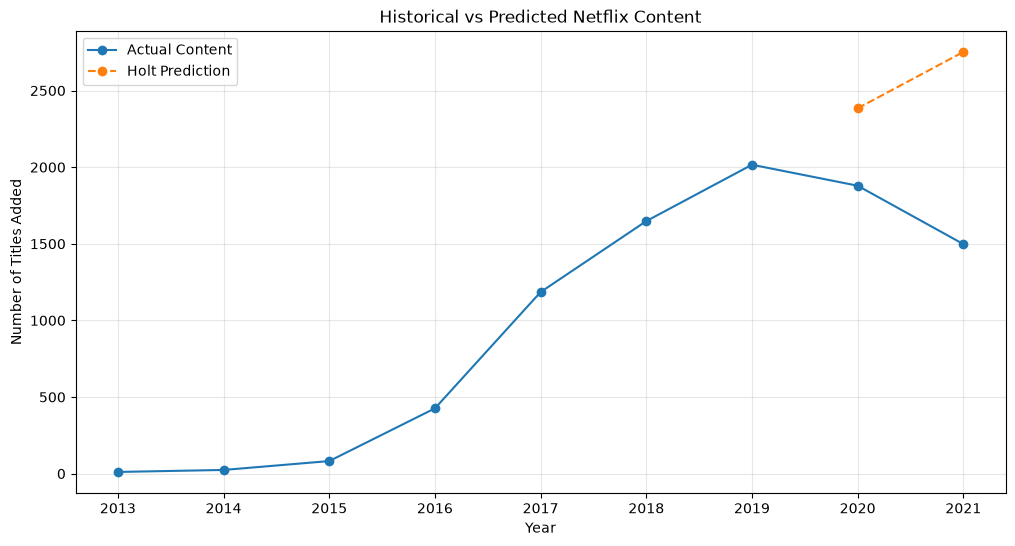

In [12]:
# ============================================
# HISTORICAL VS PREDICTED CONTENT
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    time_series.index,
    time_series.values,
    marker="o",
    label="Actual Content"
)

plt.plot(
    test_ts.index,
    holt_pred.values,
    marker="o",
    linestyle="--",
    label="Holt Prediction"
)

plt.title("Historical vs Predicted Netflix Content")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [13]:
# ============================================
# POLYNOMIAL REGRESSION - CONTENT TREND
# ============================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prepare data
X = yearly_content[["added_year"]]
y = yearly_content["title_count"]

# Chronological split
X_train = X.iloc[:-2]
X_test = X.iloc[-2:]

y_train = y.iloc[:-2]
y_test = y.iloc[-2:]

# Polynomial Regression - Degree 2
poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

# Predictions
poly_pred = poly_model.predict(X_test)

# Evaluation
poly_mae = mean_absolute_error(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))
poly_r2 = r2_score(y_test, poly_pred)

print("===== POLYNOMIAL REGRESSION PERFORMANCE =====")
print(f"MAE: {poly_mae:.2f}")
print(f"RMSE: {poly_rmse:.2f}")
print(f"R2 Score: {poly_r2:.2f}")

# Actual vs predicted
poly_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": poly_pred
}, index=X_test["added_year"])

display(poly_results.round(2))

===== POLYNOMIAL REGRESSION PERFORMANCE =====
MAE: 749.45
RMSE: 838.50
R2 Score: -18.37


,Actual,Predicted
added_year,,
2020,1879,2252.41
2021,1498,2623.49


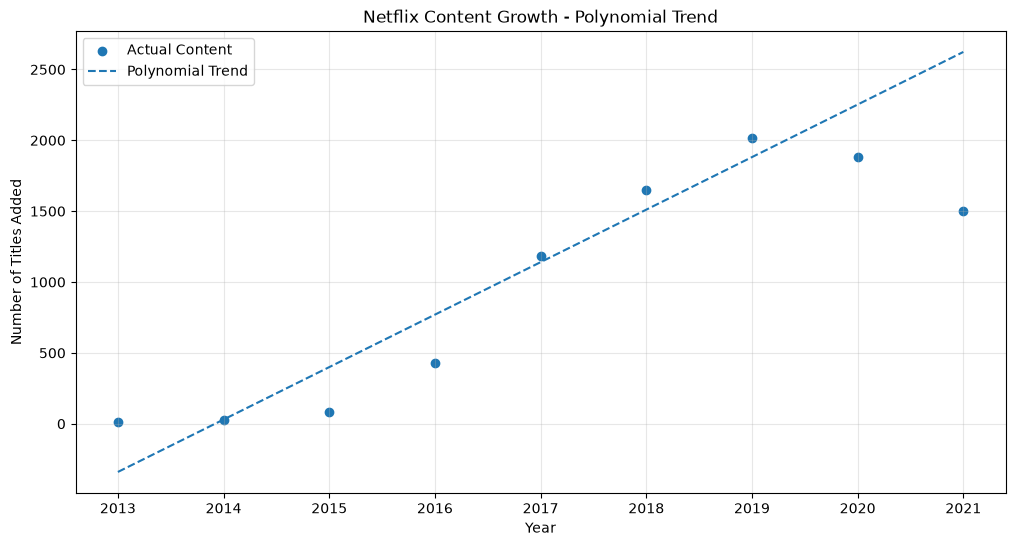

In [14]:
# ============================================
# POLYNOMIAL REGRESSION VISUALIZATION
# ============================================

plt.figure(figsize=(12, 6))

plt.scatter(
    yearly_content["added_year"],
    yearly_content["title_count"],
    label="Actual Content"
)

# Smooth prediction curve
year_range = np.arange(
    yearly_content["added_year"].min(),
    yearly_content["added_year"].max() + 1
).reshape(-1, 1)

curve_predictions = poly_model.predict(year_range)

plt.plot(
    year_range.flatten(),
    curve_predictions,
    linestyle="--",
    label="Polynomial Trend"
)

plt.title("Netflix Content Growth - Polynomial Trend")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()